# MLP simples

- 1 saida - Theta
- 2 entradas - Vd e Ve
- 1 camada
- 1 neurônio


In [1]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["VD", "VE"]
TARGET = ["Theta"]

for i in range(4):   
    Dataset = pd.read_csv(f"../Dados/Data{i + 1}.csv")
    Dataset = Dataset.drop(columns=["X", "Y", "Setpoint VD", "Setpoint VE", "tempo"])
    Dataset.index = (np.arange(0, len(Dataset), 1).astype(float) * 0.07).round(5)
    Datasets.append(Dataset)
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Datasets[i].head(5))

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  0.00  0.00
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28    0.0  2.33  2.33
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  2.33  2.33
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28   -0.0  2.33  2.33
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  0.00  0.00
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28    0.0  2.33  2.33
++++++++++++++++++++ Dataset 4 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  2.33  2.33
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28    0.0  2.33  2.33


In [2]:
NormDatasets = []

SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = Datasets[0]
TrainDataset[PREDICTORS] = SCALER.fit_transform(TrainDataset[PREDICTORS])
TrainDataset[TARGET] = OUT_SCALER.fit_transform(TrainDataset[TARGET])
NormDatasets.append(TrainDataset)

for i in range(3):
      CurrentTestDataset = Datasets[i + 1]
      CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
      CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])
      NormDatasets.append(CurrentTestDataset)
      print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
      print(NormDatasets[i].head(5))

++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
         Theta        VD        VE
0.00 -0.147046  0.098819  0.089409
0.07 -0.147046  1.268765  1.266904
0.14 -0.147046  1.268765  1.266904
0.21 -0.147046  1.268765  1.266904
0.28 -0.147046  1.268765  1.266904
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
         Theta        VD        VE
0.00 -0.147046  1.268765  1.266904
0.07 -0.147046  1.268765  1.266904
0.14 -0.147046  1.268765  1.266904
0.21 -0.147046  1.268765  1.266904
0.28 -0.147046  1.268765  1.266904
++++++++++++++++++++ Dataset Normalizado 3 +++++++++++++++++++++++
         Theta        VD        VE
0.00 -0.147046  0.098819  0.089409
0.07 -0.147046  1.268765  1.266904
0.14 -0.147046  1.268765  1.266904
0.21 -0.147046  1.268765  1.266904
0.28 -0.147046  1.268765  1.266904


In [3]:
x_train = np.array(TrainDataset[PREDICTORS])
y_train = np.array(TrainDataset[TARGET])

x_val = np.array((NormDatasets[1])[PREDICTORS])
y_val = np.array((NormDatasets[1])[TARGET])

print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

Dimensão da entrada: (2146, 2)
Dimensão da saida: (2146, 1)


In [4]:
import matplotlib.pyplot as plt

def PlotHistory(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()
    
def PlotOut(axs, title, y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    axs.scatter(time, y_true, marker='o', label='Amostras Reais')
    axs.scatter(time, y_pred, marker='x', label='Valores Preditos')
    axs.set_title(f'{title}')
    axs.set_xlabel('Theta')
    axs.set_ylabel('tempo')
    axs.legend()
    axs.grid(True)

In [5]:
from sklearn.metrics import mean_squared_error, r2_score
TITLES = ["Training", "Validation", "Test 1", "Test 2"]

def EvalModel(model):
    fig, axs = plt.subplots(4, 1, figsize=(12, 12))
    for i, dataset in enumerate(NormDatasets):
        x = np.array(dataset[PREDICTORS])
        y = OUT_SCALER.inverse_transform(dataset[TARGET])
        y_pred = OUT_SCALER.inverse_transform(model.predict(x))
    
        R2 = r2_score(y, y_pred)
        MSE = mean_squared_error(y, y_pred)
        print(f"R²_{TITLES[i]} = {R2}")
        print(f"MSE_{TITLES[i]} = {MSE}")
        
        PlotOut(axs[i], TITLES[i], y, y_pred)

In [6]:
from tensorflow import keras
from keras.callbacks import EarlyStopping

INPUT_SIZE = len(PREDICTORS)  


model = keras.models.Sequential([
    keras.layers.Input(shape=(INPUT_SIZE,)),
    keras.layers.Dense(1, activation="linear"),  
])
model.summary()
print(f"Pesos inciais:\n {model.get_weights()}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Pesos inciais:
 [array([[-1.3152119],
       [ 0.5302205]], dtype=float32), array([0.], dtype=float32)]


Configures the model for training.

In [7]:
model.compile(loss="mean_squared_error", optimizer="adam")

Trains the model for a fixed number of epochs (dataset iterations).

In [8]:
early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                patience=50,
                                restore_best_weights=True)

history = model.fit(x_train, 
                    y_train, 
                    epochs=1000,
                    callbacks=[early_stopping_monitor],
 validation_data=(x_val, y_val))

Epoch 1/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.4866 - val_loss: 1.1355
Epoch 2/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3343 - val_loss: 0.9860
Epoch 3/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2259 - val_loss: 0.8789
Epoch 4/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1058 - val_loss: 0.8058
Epoch 5/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0222 - val_loss: 0.7569
Epoch 6/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0398 - val_loss: 0.7239
Epoch 7/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9519 - val_loss: 0.7049
Epoch 8/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0046 - val_loss: 0.6949
Epoch 9/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0026 - val_loss: 0.6910
Epoch 10/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9615 - val_loss: 0.6881
Epoch 11/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0035 - val_loss: 0.6849
Epoch 12/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [9]:
print(f"Pesos finais:\n {model.get_weights()}")

Pesos finais:
 [array([[-0.89412785],
       [ 0.9098915 ]], dtype=float32), array([-0.00823453], dtype=float32)]


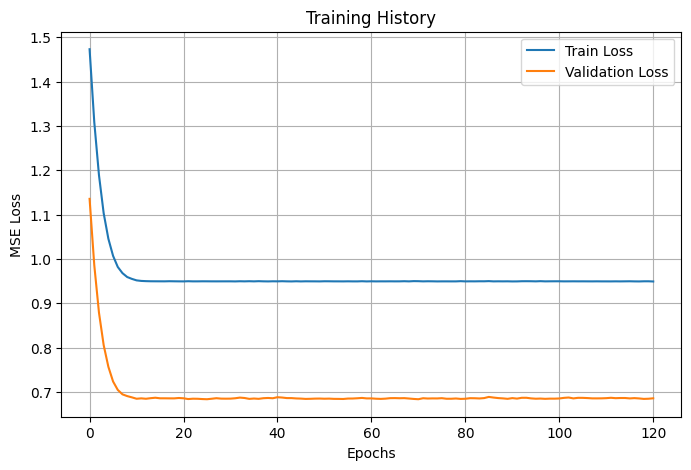

In [10]:
PlotHistory(history)

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
R²_Training = 0.05064457088637486
MSE_Training = 0.2451935096716856
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
R²_Validation = 0.0034801054807525045
MSE_Validation = 0.1766246880505605
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
R²_Test 1 = 0.06691300570993897
MSE_Test 1 = 0.23113976995742955
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
R²_Test 2 = 0.03888360964532389
MSE_Test 2 = 0.1698198759405438


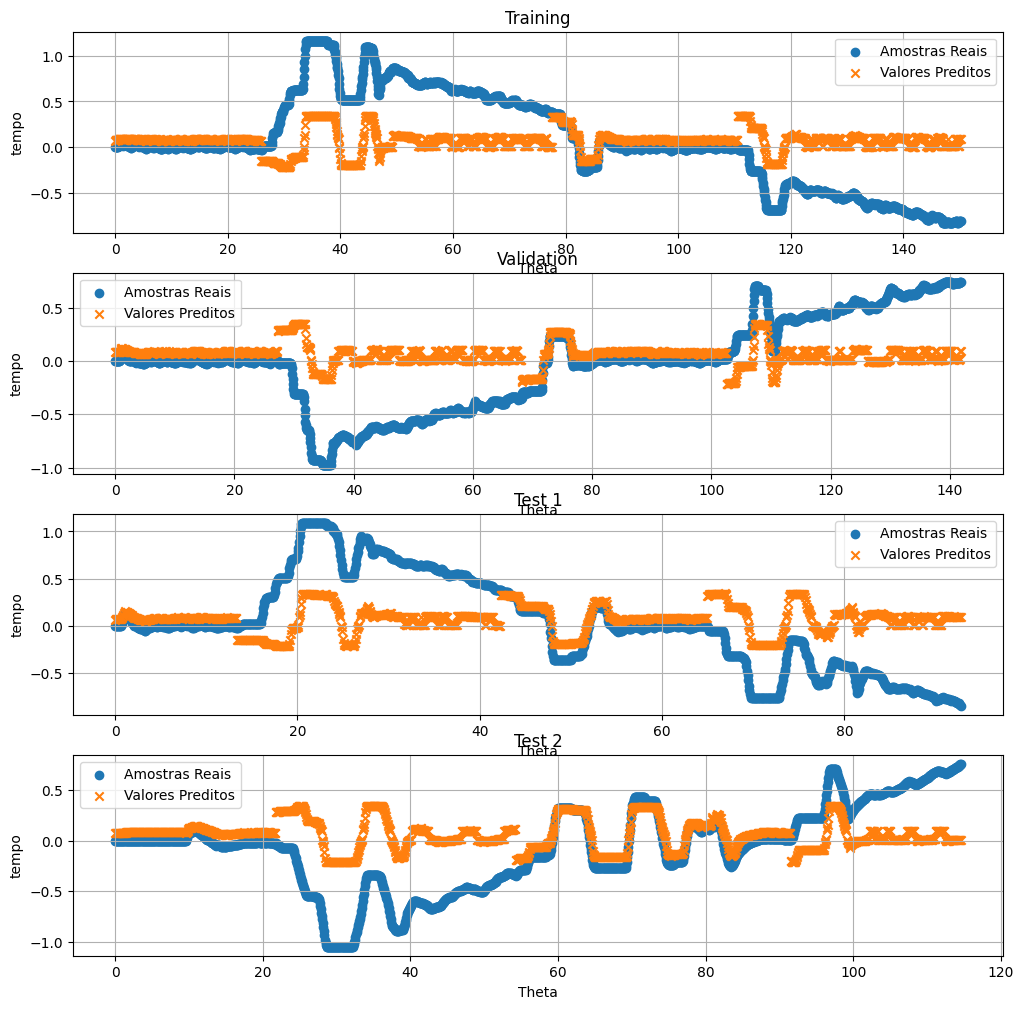

In [11]:
EvalModel(model)